# Step 3: Data Augmentation — Cluster Regression

流程：對 `new_features.csv` 做 log1p 轉換 → 相關係數選特徵 → Elbow Method 找最佳 k → KMeans 在 (log_p, log_q) 空間分群 → 各 cluster 內跑 LinearRegression → 對 `hist_features.csv` 推估 P/Q/constant，M 直接取 views。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['font.family'] = 'Arial Unicode MS'

In [2]:
PROCESSED = Path('../data/processed')
OUTPUT    = Path('../data/output')
OUTPUT.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED / 'new_features.csv')
print('new_features shape:', df.shape)

new_features shape: (224, 1084)


## 1. 資料準備

In [3]:
# log1p 轉換
df['log_p']        = np.log1p(df['p_after4d'])
df['log_q']        = np.log1p(df['q_after4d'])
df['log_constant'] = np.log1p(df['constant_after4d_time0_views'])

# LabelEncoder（加入 'unknown' 確保 hist 未見 label 不會報錯）
le = LabelEncoder()
le.fit(df['best_topic_labels'].fillna('unknown').unique().tolist() + ['unknown'])
df['best_topic_labels_enc'] = le.transform(df['best_topic_labels'].fillna('unknown'))

# AI業配判定 → 0/1
df['AI業配判定_enc'] = (
    df['AI業配判定']
    .map({True: 1, 'True': 1, False: 0, 'False': 0})
    .fillna(0).astype(int)
)

print('log_p     :', round(df['log_p'].min(), 4), '~', round(df['log_p'].max(), 4))
print('log_q     :', round(df['log_q'].min(), 4), '~', round(df['log_q'].max(), 4))
print('log_const :', round(df['log_constant'].min(), 4), '~', round(df['log_constant'].max(), 4))

log_p     : 0.0 ~ 0.4674
log_q     : 0.0 ~ 0.6855
log_const : 0.0 ~ 14.1863


/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_72601/2858229115.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['log_p']        = np.log1p(df['p_after4d'])
/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_72601/2858229115.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['log_q']        = np.log1p(df['q_after4d'])
/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_72601/2858229115.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inse

In [4]:
# 特徵選擇：計算各候選特徵與 log_p、log_q 的相關係數，取 top 5
emb_new_cols   = [c for c in df.columns if c.startswith('emb_new_')]
candidate_cols = ['duration', 'best_topic_labels_enc', 'AI業配判定_enc'] + emb_new_cols

feat_filled = df[candidate_cols].apply(lambda col: col.fillna(col.median()))
medians_sel  = feat_filled.median()

corr_p = feat_filled.corrwith(df['log_p']).abs()
corr_q = feat_filled.corrwith(df['log_q']).abs()
feat_corr = (
    pd.DataFrame({'corr_p': corr_p, 'corr_q': corr_q})
    .assign(max_corr=lambda x: x.max(axis=1))
    .sort_values('max_corr', ascending=False)
)

TOP_N             = 5
selected_features = feat_corr.head(TOP_N).index.tolist()
print(f'Top {TOP_N} 特徵（依與 log_p/log_q 的最大相關係數）：')
print(feat_corr.head(10).to_string())

Top 5 特徵（依與 log_p/log_q 的最大相關係數）：
               corr_p    corr_q  max_corr
emb_new_256  0.185995  0.243162  0.243162
emb_new_095  0.038649  0.237635  0.237635
duration     0.064928  0.232809  0.232809
emb_new_067  0.078668  0.223105  0.223105
emb_new_409  0.051357  0.211776  0.211776
emb_new_133  0.085619  0.209946  0.209946
emb_new_326  0.118834  0.209200  0.209200
emb_new_817  0.077802  0.206588  0.206588
emb_new_524  0.163633  0.204414  0.204414
emb_new_750  0.195291  0.063286  0.195291


In [5]:
# 特徵矩陣：StandardScaler fit 在全部 223 筆
scaler = StandardScaler()
X_all  = scaler.fit_transform(feat_filled[selected_features].values)
print('X_all shape:', X_all.shape)

X_all shape: (224, 5)


## 2. Elbow Method（基於 log_p, log_q 空間）

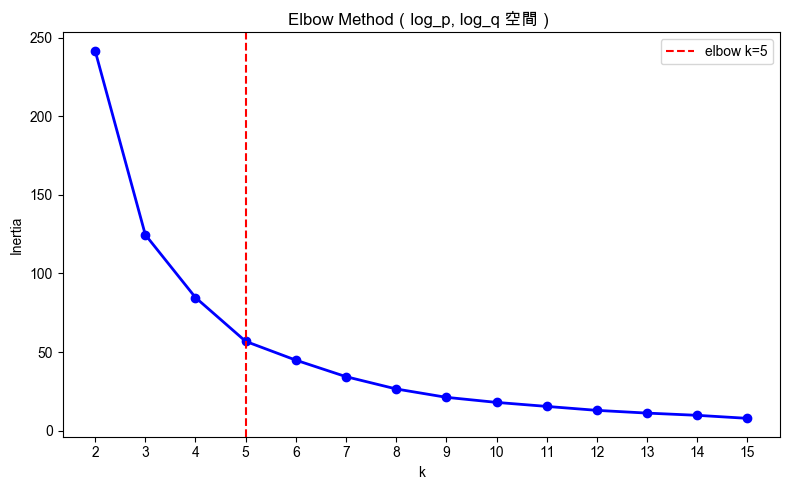

自動偵測 best_k = 5


In [6]:
scaler_cluster = StandardScaler()
X_cluster      = scaler_cluster.fit_transform(df[['log_p', 'log_q']].values)

inertias = []
K_range  = range(2, 16)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

# Kneedle 法自動偵測 elbow
k_arr   = np.array(list(K_range), dtype=float)
ine_arr = np.array(inertias)
k_n     = (k_arr - k_arr[0]) / (k_arr[-1] - k_arr[0])
i_n     = (ine_arr - ine_arr[-1]) / (ine_arr[0] - ine_arr[-1])
best_k  = int(k_arr[np.argmax(np.abs(k_n + i_n - 1) / np.sqrt(2))])
best_k  = max(3, best_k)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_range), inertias, 'bo-', linewidth=2)
ax.axvline(x=best_k, color='red', linestyle='--', label=f'elbow k={best_k}')
ax.set_xlabel('k')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method（log_p, log_q 空間）')
ax.set_xticks(list(K_range))
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT / 'elbow.png', dpi=150)
plt.show()
print(f'自動偵測 best_k = {best_k}')

## 3. KMeans 分群

In [7]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster)

print('各 Cluster 大小：')
print(df['cluster'].value_counts().sort_index().to_string())

各 Cluster 大小：
cluster
0    69
1    46
2    59
3    12
4    38


/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_72601/939471405.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster'] = kmeans.fit_predict(X_cluster)


## 4. Train/Test Split（80/20，stratified by cluster）

In [8]:
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42,
    stratify=df['cluster'].values
)

print(f'train: {len(train_idx)} 筆, test: {len(test_idx)} 筆')
print('train cluster 分布：')
print(pd.Series(df['cluster'].values[train_idx]).value_counts().sort_index().to_string())

train: 179 筆, test: 45 筆
train cluster 分布：
0    55
1    37
2    47
3    10
4    30


## 5. Per-Cluster LinearRegression + 評估

In [9]:
targets         = ['log_p', 'log_q', 'log_constant']
global_fallback = {t: df[t].median() for t in targets}

cluster_models = {}
for c in range(best_k):
    mask_c = df['cluster'].values[train_idx] == c
    n_c    = mask_c.sum()
    if n_c < 2:
        print(f'Cluster {c}: 只有 {n_c} 筆 train，使用全體中位數 fallback')
        cluster_models[c] = None
        continue
    X_c = X_all[train_idx][mask_c]
    cluster_models[c] = {
        t: LinearRegression().fit(X_c, df[t].values[train_idx][mask_c])
        for t in targets
    }
    print(f'Cluster {c}: {n_c} 筆 train → 迴歸完成')

Cluster 0: 55 筆 train → 迴歸完成
Cluster 1: 37 筆 train → 迴歸完成
Cluster 2: 47 筆 train → 迴歸完成
Cluster 3: 10 筆 train → 迴歸完成
Cluster 4: 30 筆 train → 迴歸完成


In [10]:
rows = []
for c in range(best_k):
    mask_c = df['cluster'].values[test_idx] == c
    if mask_c.sum() == 0:
        continue
    X_tc = X_all[test_idx][mask_c]
    for t in targets:
        y_true = df[t].values[test_idx][mask_c]
        y_pred = (
            cluster_models[c][t].predict(X_tc)
            if cluster_models[c] is not None
            else np.full(mask_c.sum(), global_fallback[t])
        )
        rows.append({
            'cluster': c,
            'target' : t,
            'n_test' : int(mask_c.sum()),
            'MAE'    : mean_absolute_error(y_true, y_pred),
            'RMSE'   : np.sqrt(mean_squared_error(y_true, y_pred)),
        })

eval_df = pd.DataFrame(rows)
print(eval_df.to_string(index=False))
print(f'\n整體 RMSE 總和：{eval_df["RMSE"].sum():.4f}')

 cluster       target  n_test      MAE     RMSE
       0        log_p      14 0.028058 0.032910
       0        log_q      14 0.011370 0.039105
       0 log_constant      14 0.902680 1.089120
       1        log_p       9 0.014980 0.031496
       1        log_q       9 0.068115 0.079482
       1 log_constant       9 1.693386 3.274311
       2        log_p      12 0.016072 0.021491
       2        log_q      12 0.023679 0.033019
       2 log_constant      12 1.261603 1.593382
       3        log_p       2 0.139460 0.161071
       3        log_q       2 0.108703 0.109461
       3 log_constant       2 2.739070 3.264966
       4        log_p       8 0.062761 0.093917
       4        log_q       8 0.013962 0.016333
       4 log_constant       8 2.340469 3.484349

整體 RMSE 總和：13.3244


## 6. 對 hist_features 預測

In [11]:
hist = pd.read_csv(PROCESSED / 'hist_features.csv', low_memory=False)
print('hist_features shape:', hist.shape)

# 編碼 hist 的類別特徵
known_labels = set(le.classes_)
hist['best_topic_labels_enc'] = le.transform(
    hist['best_topic_labels'].fillna('unknown')
         .apply(lambda x: x if x in known_labels else 'unknown')
)
hist['AI業配判定_enc'] = (
    hist['AI業配判定']
    .map({True: 1, 'True': 1, False: 0, 'False': 0})
    .fillna(0).astype(int)
)

# 用 train 中位數填補缺值，套用同一 scaler
hist_feat = hist[selected_features].fillna(medians_sel[selected_features])
X_hist    = scaler.transform(hist_feat.values)
print('X_hist shape:', X_hist.shape)

hist_features shape: (10375, 1083)
X_hist shape: (10375, 5)


/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_72601/3576025474.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hist['best_topic_labels_enc'] = le.transform(
/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_72601/3576025474.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hist['AI業配判定_enc'] = (


In [12]:
# 用 input features → (log_p_est, log_q_est) 的全量迴歸推估 cluster 歸屬，
# 再用 KMeans.predict 指派 cluster
global_reg_p = LinearRegression().fit(X_all, df['log_p'].values)
global_reg_q = LinearRegression().fit(X_all, df['log_q'].values)

log_p_est = global_reg_p.predict(X_hist)
log_q_est = global_reg_q.predict(X_hist)

hist['cluster'] = kmeans.predict(
    scaler_cluster.transform(np.column_stack([log_p_est, log_q_est]))
)

print('hist cluster 分布：')
print(hist['cluster'].value_counts().sort_index().to_string())

hist cluster 分布：
cluster
0    10187
1       87
2       35
3       66


/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_72601/1165295241.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hist['cluster'] = kmeans.predict(


In [13]:
# 以全部 223 筆重新 fit 最終模型（評估用 train-only 模型，輸出用全量模型）
final_models = {}
for c in range(best_k):
    mask_c = df['cluster'].values == c
    if mask_c.sum() < 2:
        final_models[c] = None
        continue
    X_c = X_all[mask_c]
    final_models[c] = {
        t: LinearRegression().fit(X_c, df[t].values[mask_c])
        for t in targets
    }

# 向量化預測
hist_p     = np.zeros(len(hist))
hist_q     = np.zeros(len(hist))
hist_const = np.zeros(len(hist))

for c in range(best_k):
    mask_h = hist['cluster'].values == c
    if mask_h.sum() == 0:
        continue
    X_h = X_hist[mask_h]
    if final_models[c] is not None:
        hist_p[mask_h]     = np.expm1(final_models[c]['log_p'].predict(X_h))
        hist_q[mask_h]     = np.expm1(final_models[c]['log_q'].predict(X_h))
        hist_const[mask_h] = np.expm1(final_models[c]['log_constant'].predict(X_h))
    else:
        hist_p[mask_h]     = np.expm1(global_fallback['log_p'])
        hist_q[mask_h]     = np.expm1(global_fallback['log_q'])
        hist_const[mask_h] = np.expm1(global_fallback['log_constant'])

hist_p     = hist_p.clip(0)
hist_q     = hist_q.clip(0)
hist_const = hist_const.clip(0)

In [14]:
out_df = pd.DataFrame({
    'reels_shortcode': hist['reels_shortcode'].values,
    'p'              : hist_p,
    'q'              : hist_q,
    'M'              : hist['views'].values,
    'constant'       : hist_const,
    'cluster'        : hist['cluster'].values,
})

out_path = OUTPUT / 'augmented_hist.csv'
out_df.to_csv(out_path, index=False)
print(f'已儲存：{out_path}')
print(out_df.shape)
print(out_df.head())

已儲存：../data/output/augmented_hist.csv
(10375, 6)
  reels_shortcode         p         q    M      constant  cluster
0     DPeT4BHExo-  0.121143  0.000352  243  36296.377352        0
1     DPZEm_oExnd  0.121229  0.000747  266  36099.044196        0
2     DLvRZSlTBzn  0.121746  0.003137   37  34930.695235        0
3     DIvNtToTBL-  0.121476  0.001892  231  35534.539494        0
4     Ciksu1-vDBo  0.122095  0.004755  309  34162.798415        0
